<a href="https://colab.research.google.com/github/lgplorea/EjerciciosPython/blob/main/PrediccionSalarial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Regresión lineal que predice y marca una línea recta en los datos que se calculan a quince años de salario,

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
#Aseguramos subir archivo
df = pd.read_csv("Salary.csv")
#Verificamos que ha cargado bien
print(df.head())

   YearsExperience  Salary
0              1.1   39343
1              1.3   46205
2              1.5   37731
3              2.0   43525
4              2.2   39891


Coeficiente de determinación (R^2): 0.9708
Error cuadrático medio (MSE): 16561691.22


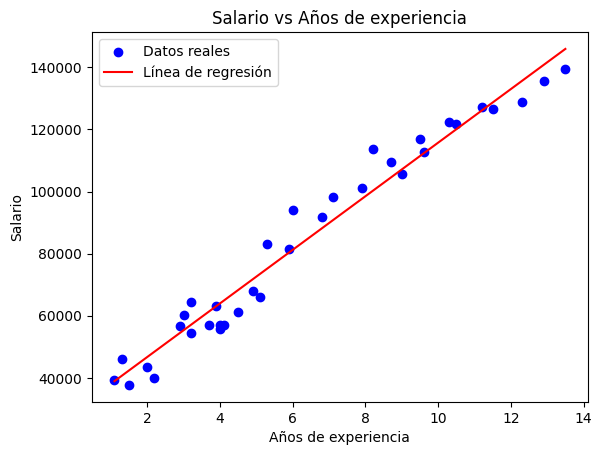

In [6]:
#Paso 1: la preparación de los datos
#Convertimos las columnas a valores numéricos(arrays en numpy) para scikit-learn.
# X debe ser una matriz bidimensional(n_muestras, n_caracteristicas)
X = df[["YearsExperience"]].values.reshape(-1, 1) #Los corchetes dobles para tabla bidimensional
# y es el vector objetivo (nuestro salario), una matriz unidimensional
y = df["Salary"].values.reshape(-1, 1) #Un corchete para tabla unidimensional


#Paso 2: división de los datos(train/test)
#importamos la función para separar los datos
from sklearn.model_selection import train_test_split
#Separamos (split) los datos en entrenamiento y prueba
#Dividimos 80% para entrenar el modelo y 20% para probar su precisión
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
#X variable independiente, y variable dependiente


#Paso 3: Entrenamiento de modelo
#Craemos la instancia del modelo de regresión lineal
model=LinearRegression()
#Entrenamos el modelo
#Aquí la IA aprende la relación lineal entre X e y
model.fit(X_train, y_train)


#Paso 4: hacemos la predicción y evaluación
#Hacemos predicciones usando los datos de prueba (que el modelo nunca vio)
y_pred = model.predict(X_test)

#importamos métricas de evaluación para ver si el modelo funciona bien
from sklearn.metrics import mean_squared_error, r2_score

#calculamos R^2: indica qué tan bien se ajusta el modelo a los datos(1.0 es perfecto)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"Coeficiente de determinación (R^2): {r2:.4f}") #quiero 4 números flotantes (decimales)
print(f"Error cuadrático medio (MSE): {mse:.2f}")

#Paso 5 Visualización. Pintamos los datos reales.
plt.scatter(X,y, color='blue', label='Datos reales')
#pintamos la línea roja que es lo que el modelo ha aprendido
plt.plot(X, model.predict(X), color='red', label='Línea de regresión')
plt.title('Salario vs Años de experiencia')
plt.xlabel('Años de experiencia')
plt.ylabel('Salario')
plt.legend()
plt.show()



El MSE mide la calidad de tu modelo de regresión. Te dice qué tan lejos están, en promedio, los puntos azules (datos reales) de la línea roja (la predicción).

¿Cómo se calcula textualmente?Para cada punto azul, el modelo calcula la distancia vertical exacta hasta la línea roja (eso es el "error" o residuo). Luego, hace lo siguiente:Eleva cada error al cuadrado (para que los errores negativos y positivos no se cancelen entre sí y para penalizar más los errores grandes).Suma todos esos cuadrados.Saca el promedio.

¿Cómo interpretar tu valor ($16,561,691.22$)?A primera vista, un MSE de 16.5 millones asusta y parece enorme. Sin embargo, tiene un truco: está en unidades al cuadrado. Como tu eje Y es "Salario" (en dinero), las unidades de tu MSE son "dólares (o pesos) al cuadrado", lo cual no tiene sentido intuitivo para nuestra mente.

Para interpretarlo en el "mundo real", lo ideal es sacarle la raíz cuadrada al MSE (lo que se conoce como RMSE o Root Mean Squared Error):$$\text{RMSE} = \sqrt{16,561,691.22} \approx 4,069.60$$

La interpretación real:En promedio, las predicciones de salario de tu línea roja se equivocan por aproximadamente 4,070 unidades de dinero (pesos/dólares) respecto al salario real de las personas.

¿Es un buen modelo?Sí, es un modelo excelente. No debes mirar el MSE de forma aislada. Si te fijas en tu otra métrica, el Coeficiente de determinación ($R^2$) es de $0.9708$. Esto significa que los años de experiencia explican el 97.08% de la variación en el salario.Dado que los salarios de la gráfica van desde los 40,000 hasta casi los 140,000, un error promedio de apenas ~4,000 es bastante pequeño y aceptable. Tu línea roja se ajusta muy bien a los puntos.